# MapleFreight Delivery Delay Prediction & Slack Alerts
**Author:** Anush Adhikari | **ID:** C0968893

## 1. Problem and Objective
MapleFreight's on-time rate fell from 94% to 88%, and delays are only found after the customer calls. This notebook builds a model that predicts which in-transit shipments will be late and sends a Slack alert to dispatch while there is still time to act.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid") # RANDOM_STATE constant makes results repeatable, so every later model uses the same seed.
RANDOM_STATE = 42

# Load data
df = pd.read_csv("maplefreight_delivery_delay_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


## 2. Data Understanding
Checking size, types, missing values, duplicates, spellings and units.

## structure and missing values

In [2]:
# Types and missing values
df.info()
df.isna().sum()[df.isna().sum() > 0]

<class 'pandas.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   str    
 1   origin_city                6035 non-null   str    
 2   destination_city           6035 non-null   str    
 3   carrier                    6035 non-null   str    
 4   service_level              6035 non-null   str    
 5   goods_type                 6035 non-null   str    
 6   customer_priority_tier     6035 non-null   str    
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minutes       6035 non-null   float64
 14  dri

driver_experience_years    210
weather_condition          150
traffic_index              121
fuel_cost_cad              240
dtype: int64

## duplicates

In [3]:
# Duplicate rows and repeated shipment IDs
print("Identical rows:", df.duplicated().sum())
print("Repeated shipment_id:", df["shipment_id"].duplicated().sum())

Identical rows: 32
Repeated shipment_id: 35


## spellings and target balance

In [4]:
# Inconsistent spellings and class balance
print(df["service_level"].value_counts())
print(df["delivered_late"].value_counts(normalize=True).round(3))

service_level
Standard    3219
Express     1442
Economy     1254
standard      74
express       27
economy       19
Name: count, dtype: int64
delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


## unit check on weight

In [5]:
# Weight outliers (possible grams entered as kg)
print((df["weight_kg"] > 10000).sum(), "rows above 10,000 kg")
df["weight_kg"].describe()

40 rows above 10,000 kg


count    6.035000e+03
mean     6.928251e+03
std      8.375515e+04
min      3.000000e+01
25%      4.960000e+02
50%      8.271000e+02
75%      1.286300e+03
max      2.999300e+06
Name: weight_kg, dtype: float64

**Findings**
- 6,035 rows, 23 columns; about 20.6% of shipments are late.
- Missing values in driver_experience_years (210), weather_condition (150), traffic_index (121) and fuel_cost_cad (240).
- 32 identical rows and 35 repeated shipment IDs.
- `service_level` has 6 data (capital and normal words) instead of 3. `(Standard, standard, Express, express, Economy, economy)`
- 40 weights are above 10,000 kg, likely grams entered as kg.
- `actual_transit_hours` is only known after delivery, so it will be dropped to avoid leakage.

# 3. Data Cleaning
Fixing spellings and units, removing duplicates and dropping the leakage column. Missing values are filled after the train/test split.

## spellings

In [6]:
# Standardise service_level to Express / Standard / Economy
df["service_level"] = df["service_level"].str.strip().str.title()
print(df["service_level"].value_counts())

service_level
Standard    3293
Express     1469
Economy     1273
Name: count, dtype: int64


## duplicates

In [7]:
# Drop duplicates (identical rows, then repeated IDs)
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset="shipment_id").reset_index(drop=True)
print("Rows removed:", before - len(df), "| Rows left:", len(df))

Rows removed: 35 | Rows left: 6000


## weight units


In [8]:
# Weights above 10,000 are grams entered as kg, so divide by 1000
bad = df["weight_kg"] > 10000
print("Fixed rows:", bad.sum())
df.loc[bad, "weight_kg"] = df.loc[bad, "weight_kg"] / 1000
df["weight_kg"].describe()

Fixed rows: 40


count    6000.000000
mean      953.857233
std       618.390918
min        30.000000
25%       494.650000
50%       823.450000
75%      1274.425000
max      5044.000000
Name: weight_kg, dtype: float64

## drop leakage cloumns


In [9]:
# Remove the column that is only known after delivery
df = df.drop(columns=["actual_transit_hours"])
print("Columns left:", df.shape[1])

Columns left: 22


**Findings**
- service_level now has 3 clean categories.
- 35 duplicate rows removed , leaving 6,000 shipments.
- 40 weights were in grams and were converted to kg; the maximum is now about 3,000 kg.
- `actual_transit_hours` dropped to prevent data leakage.
- Missing values will be filled after the split.

# **4. Exploratory Data Analysis (EDA)**
Which factors are linked to late delivery?

## target balance

delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


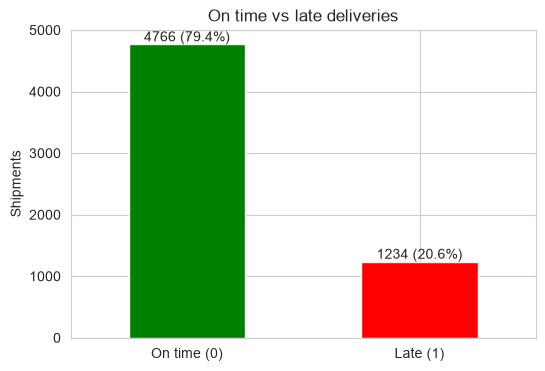

In [10]:
# Class balance
counts = df["delivered_late"].value_counts().sort_index()
print(df["delivered_late"].value_counts(normalize=True).round(3))

ax = counts.plot(kind="bar", color=["green", "red"], figsize=(6, 4))
ax.set_title("On time vs late deliveries")
ax.set_xticklabels(["On time (0)", "Late (1)"], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("Shipments")

# Count and % on each bar
for i, v in enumerate(counts):
    ax.text(i, v + 50, f"{v} ({v/len(df):.1%})", ha="center")
plt.show()

## late rate by category

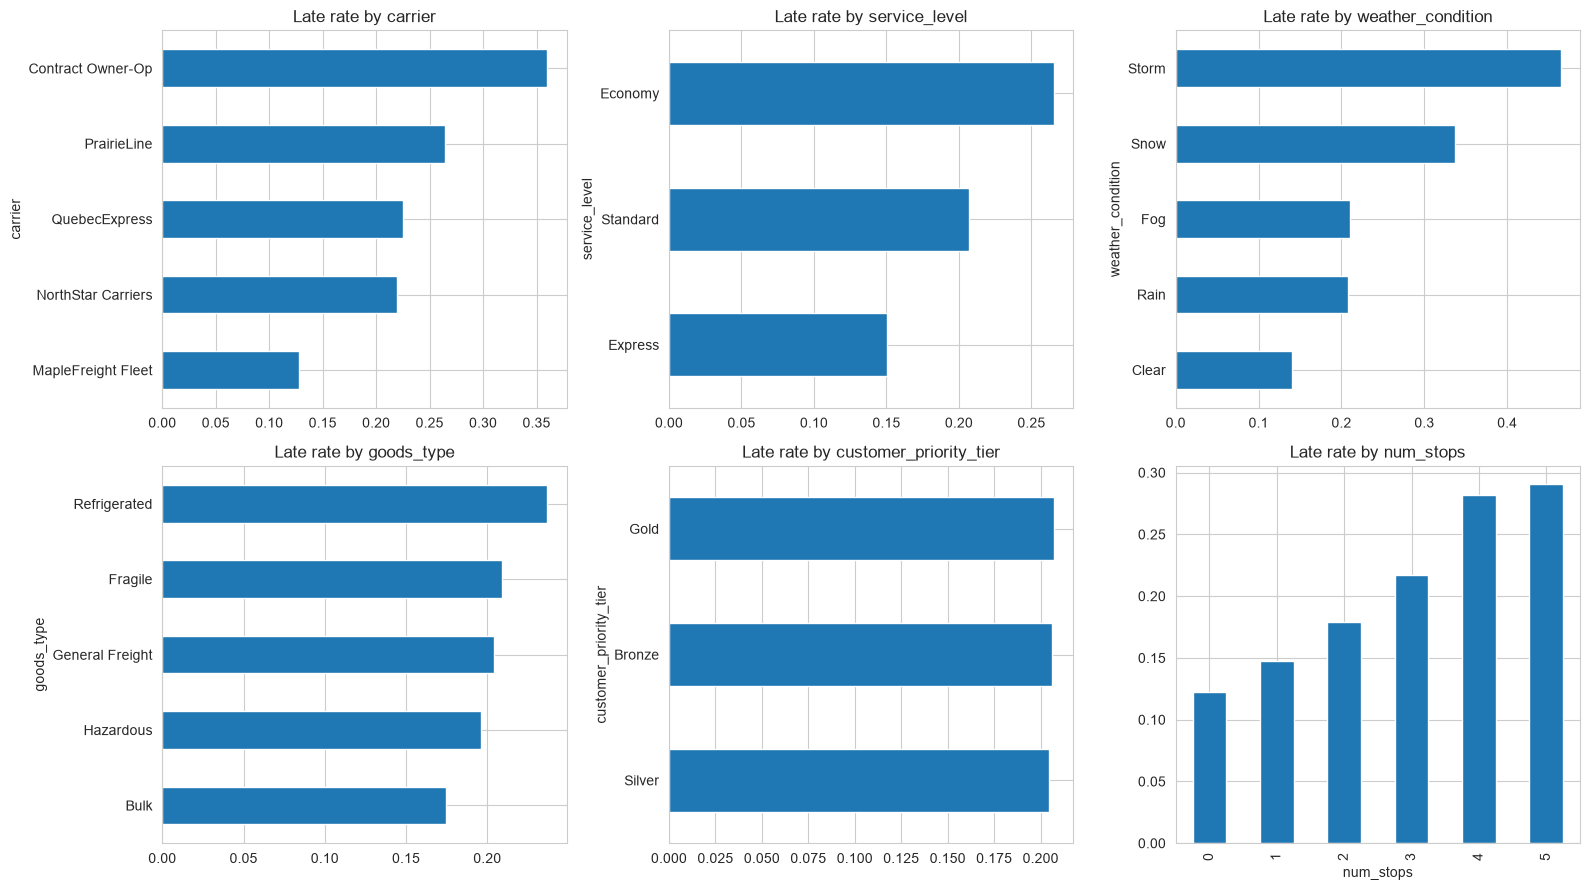

In [11]:
# Late rate for each category column
cats = ["carrier", "service_level", "weather_condition", "goods_type", "customer_priority_tier"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, cats):
# Plot late rate by category
    df.groupby(c)["delivered_late"].mean().sort_values().plot(kind="barh", ax=ax, title=f"Late rate by {c}")
    # Add counts on each bar
    # counts = df[c].value_counts()
df.groupby("num_stops")["delivered_late"].mean().plot(kind="bar", ax=axes.flat[5], title="Late rate by num_stops")
plt.tight_layout()
plt.show()

## numeric and correlation

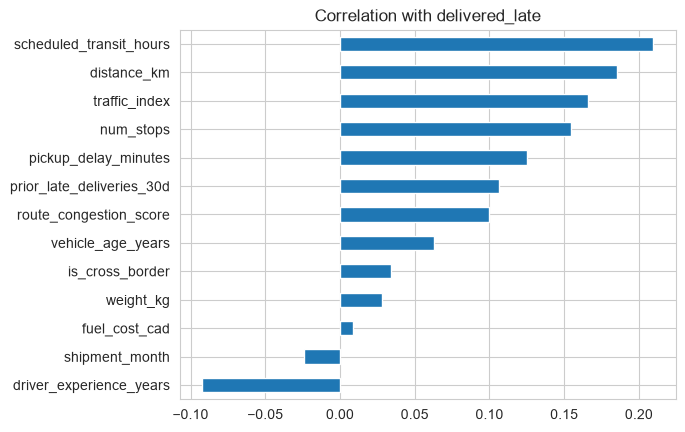

In [12]:
# Correlation of numeric features with the target
corr = df.select_dtypes("number").corr()["delivered_late"].drop("delivered_late").sort_values()
corr.plot(kind="barh", title="Correlation with delivered_late")
plt.show()

## Late rate because of late pickup or delay

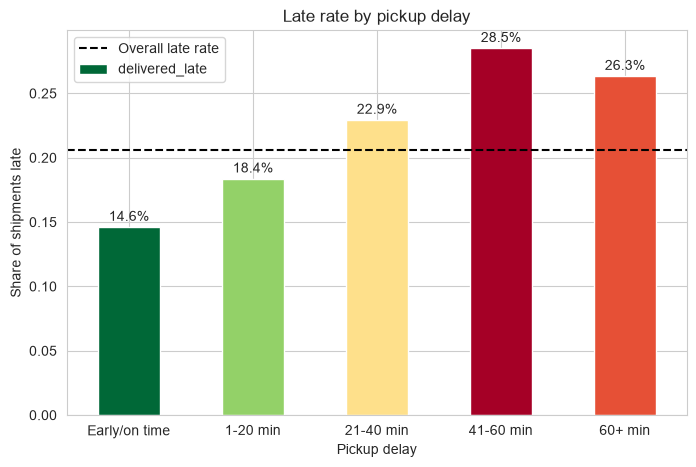

In [13]:
# Late rate by pickup delay
bins = [-25, 0, 20, 40, 60, 150]
labels = ["Early/on time", "1-20 min", "21-40 min", "41-60 min", "60+ min"]
df["pickup_group"] = pd.cut(df["pickup_delay_minutes"], bins, labels=labels)

rate = df.groupby("pickup_group", observed=True)["delivered_late"].mean()
colors = plt.cm.RdYlGn_r((rate - rate.min()) / (rate.max() - rate.min()))

# late rate by pickup delay bar chart with overall late rate line
ax = rate.plot(kind="bar", color=colors, figsize=(8, 5))
ax.axhline(df["delivered_late"].mean(), color="black", linestyle="--", label="Overall late rate")
ax.set_title("Late rate by pickup delay")
ax.set_xlabel("Pickup delay")
ax.set_ylabel("Share of shipments late")
ax.set_xticklabels(labels, rotation=0)
# Add counts and % on each bar
for i, v in enumerate(rate): # e
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")
ax.legend()
plt.show()

df = df.drop(columns="pickup_group")  # helper column, not needed later

**Findings**
- Class imbalance: about 20.6% of shipments are late. (close to 21% as mentioned in the question)
- Weather is a strong driver: late rate is 14% in clear weather, 34% in snow and 47% in storms.
- Carrier matters: Contract Owner-Op is late 36% of the time vs 13% for MapleFreight Fleet.
- Service level: Economy 27% late vs Express 15%.
- More stops means more delays: 12% with no stops, 29% with five.
- Customer tier, origin and destination city show almost no difference (all about 19-23%), so they are weak predictors.
- Top numeric correlations: scheduled_transit_hours (0.21), distance_km (0.19), traffic_index (0.17), num_stops (0.16), pickup_delay_minutes (0.13). Experienced drivers are slightly less late (-0.09).

# **Feature enginerring and Data preparation**

Creating new features from information available at dispatch, then splitting into train and test sets. Missing values are filled inside the model pipeline, using training data only.

## new features

In [14]:
# New features (all known before delivery)
df["required_speed_kmh"] = df["distance_km"] / df["scheduled_transit_hours"]
df["stops_per_100km"] = df["num_stops"] / df["distance_km"] * 100
df["severe_weather"] = df["weather_condition"].isin(["Snow", "Storm"]).astype(int)
df["pickup_late_flag"] = (df["pickup_delay_minutes"] > 20).astype(int)

df[["required_speed_kmh", "stops_per_100km", "severe_weather", "pickup_late_flag", "delivered_late"]].corr()["delivered_late"].round(3)

required_speed_kmh   -0.043
stops_per_100km       0.019
severe_weather        0.195
pickup_late_flag      0.115
delivered_late        1.000
Name: delivered_late, dtype: float64

## features, target and split

In [15]:
from sklearn.model_selection import train_test_split

# shipment_id is just a label, so it is not a feature
X = df.drop(columns=["shipment_id", "delivered_late"])
y = df["delivered_late"]

# stratify keeps the 21% late share equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Late share - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (4800, 24) | Test: (1200, 24)
Late share - train: 0.206 | test: 0.206


The 24 counts the original columns minus shipment_id and the target, plus the 4 new ones.

**Findings**
- Added severe_weather (correlation 0.20 with late) and pickup_late_flag (0.12); both are useful.
- `required_speed_kmh` (-0.04) and stops_per_100km (0.02) are weak on their own, but they are kept and the models will show whether they help.
- Data split 80/20 with stratification: 4,800 train and 1,200 test rows, each about 20.6% late.
- The test set is kept untouched until final evaluation.

# **6. Data Preprocessing**
Filling missing values, scaling numeric features and encoding categories. Fitted on the training set only to avoid leakage.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = X_train.select_dtypes("object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Numbers: fill gaps with median, then scale. Categories: fill gaps with "Unknown", then one-hot encode
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

# Fit on train only, then apply to both
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print("Categorical:", cat_cols)
print("Numeric columns:", len(num_cols))
print("Processed shapes:", X_train_p.shape, X_test_p.shape)

Categorical: ['origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'weather_condition']
Numeric columns: 17
Processed shapes: (4800, 56) (1200, 56)


**Findings**
- Numeric gaps filled with the median; missing weather set to "Unknown".
- Numeric features scaled; 7 categorical columns one-hot encoded.
- The data became 56 numeric columns with no missing values: 4,800 train rows and 1,200 test rows.
- Everything was fitted on training data only, so the test set stays unseen.

# **7. Baseline Models**
A "predict on time" dummy and a logistic regression with class weights. Every later model is compared against these.

## helping function

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

results = []

def evaluate(name, model):
    """Print metrics, draw confusion matrix, store results"""
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    row = {"Model": name,
           "Accuracy": accuracy_score(y_test, pred),
           "Precision": precision_score(y_test, pred, zero_division=0),
           "Recall": recall_score(y_test, pred),
           "F1": f1_score(y_test, pred),
           "ROC-AUC": roc_auc_score(y_test, prob)}
    results.append(row)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["On time", "Late"]).plot(cmap="Blues")
    plt.title(name)
    plt.show()
    return pd.Series({k: v for k, v in row.items() if k != "Model"}).round(3)

## dummy baseline

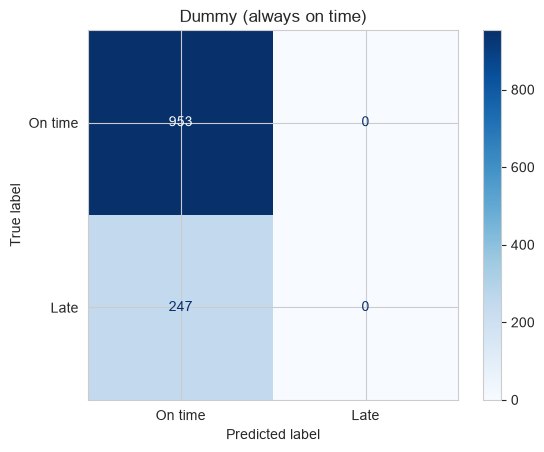

Accuracy     0.794
Precision    0.000
Recall       0.000
F1           0.000
ROC-AUC      0.500
dtype: float64

In [18]:
# Always predicts "on time"
dummy = Pipeline([("pre", preprocessor), ("model", DummyClassifier(strategy="most_frequent"))])
dummy.fit(X_train, y_train)
evaluate("Dummy (always on time)", dummy)

## Logistic Regression

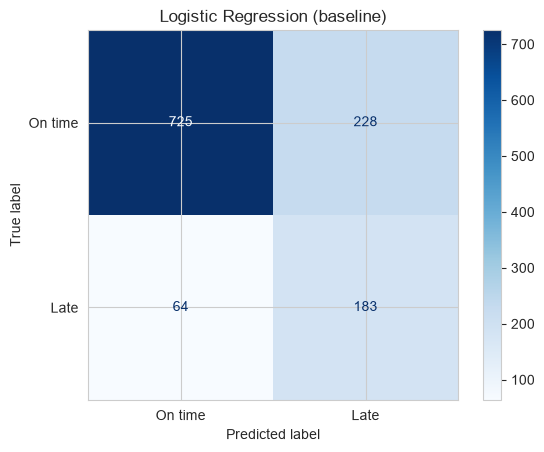

Accuracy     0.757
Precision    0.445
Recall       0.741
F1           0.556
ROC-AUC      0.830
dtype: float64

In [19]:
# class_weight="balanced" makes late shipments count more during training
logreg = Pipeline([("pre", preprocessor),
                   ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)
evaluate("Logistic Regression (baseline)", logreg)

# **8. Stronger Models**
Random forest and gradient boosting, both with class weights, compared against the logistic regression baseline.

## Random forest

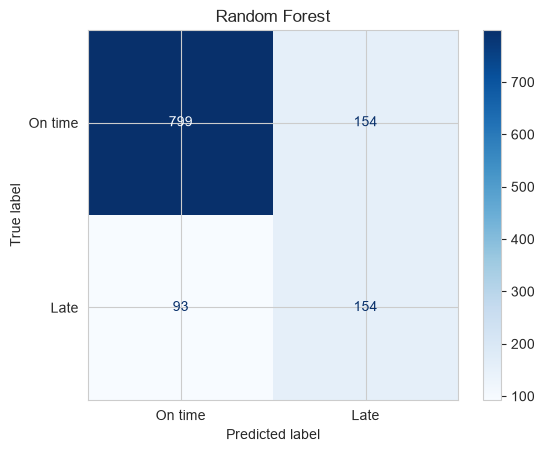

Accuracy     0.794
Precision    0.500
Recall       0.623
F1           0.555
ROC-AUC      0.812
dtype: float64

In [20]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Depth and leaf size are limited to avoid overfitting
rf = Pipeline([("pre", preprocessor),
               ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)
evaluate("Random Forest", rf)

# Gradient Boosting

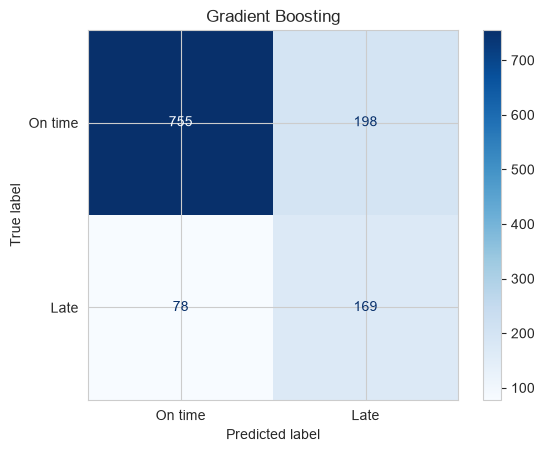

Accuracy     0.770
Precision    0.460
Recall       0.684
F1           0.550
ROC-AUC      0.814
dtype: float64

In [21]:
# Gradient boosting builds trees one after another, each fixing the last one's mistakes
gb = Pipeline([("pre", preprocessor),
               ("model", HistGradientBoostingClassifier(class_weight="balanced", learning_rate=0.05, max_iter=200, max_depth=4, random_state=RANDOM_STATE))])
gb.fit(X_train, y_train)
evaluate("Gradient Boosting", gb)

## Comparison Table

In [22]:
# Compare all models
pd.DataFrame(results).round(3).set_index("Model")


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Dummy (always on time),0.794,0.000,0.000,0.000,0.500
Logistic Regression (baseline),0.757,0.445,0.741,0.556,0.830
Random Forest,0.794,0.500,0.623,0.555,0.812
Gradient Boosting,0.770,0.460,0.684,0.550,0.814


In [23]:
# Remove duplicate runs, keep the latest of each model
results_df = pd.DataFrame(results).drop_duplicates(subset="Model", keep="last").set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Dummy (always on time),0.794,0.000,0.000,0.000,0.500
Logistic Regression (baseline),0.757,0.445,0.741,0.556,0.830
Random Forest,0.794,0.500,0.623,0.555,0.812
Gradient Boosting,0.770,0.460,0.684,0.550,0.814


**Findings**
- Random forest: precision 0.50, recall 0.62, F1 0.56, ROC-AUC 0.81.
- Gradient boosting: precision 0.46, recall 0.68, F1 0.55, ROC-AUC 0.81.
- Logistic regression (baseline): precision 0.45, recall 0.74, F1 0.56, ROC-AUC 0.83.
- The complex models did not beat the simple baseline. This suggests the late-delivery signal is mostly simple and additive (weather, stops, carrier), so extra complexity adds little.
- Logistic regression is also easier to explain to dispatch, so it will be the final model unless tuning changes the picture.

***Why logistic regression has lower accuracy but is better***
- It flags more shipments as risky. Some of those are false alarms, which pulls accuracy down to 0.757. But it also catches 74% of the late shipments, so it's far more useful.

# **9. Alert Threshold and Final Evaluation**
Choosing the probability cutoff for Slack alerts. The threshold is picked using cross-validation on training data only, then checked once on the test set.

## threshold table on training data

In [24]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# Final model: logistic regression
final_model = Pipeline([("pre", preprocessor),
                        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])

# Out-of-fold risk scores on training data (each row scored by a model that never saw it)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

rows = []
for t in np.arange(0.30, 0.91, 0.05):
    p = (oof >= t).astype(int)
    rows.append({"threshold": round(t, 2),
                 "precision": precision_score(y_train, p),
                 "recall": recall_score(y_train, p),
                 "f1": f1_score(y_train, p),
                 "alerts": p.sum()})
threshold_table = pd.DataFrame(rows).round(3)
threshold_table

,threshold,precision,recall,f1,alerts
0,0.30,0.317,0.887,0.467,2757
1,0.35,0.341,0.854,0.487,2474
2,0.40,0.364,0.814,0.503,2207
3,0.45,0.390,0.771,0.518,1949
4,0.50,0.416,0.726,0.529,1724
5,0.55,0.449,0.673,0.539,1478
6,0.60,0.480,0.616,0.539,1267
7,0.65,0.510,0.548,0.528,1061
8,0.70,0.550,0.482,0.514,865
9,0.75,0.591,0.404,0.480,675


## Plot

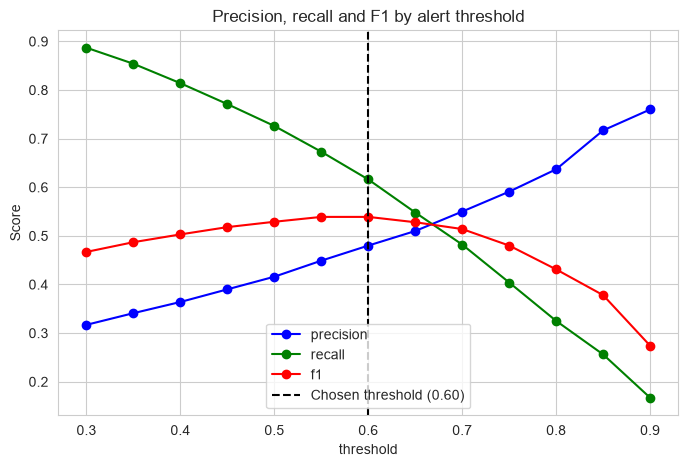

In [25]:
# Precision / recall / F1 vs threshold
ax = threshold_table.set_index("threshold")[["precision", "recall", "f1"]].plot(
    marker="o", figsize=(8, 5), color=["blue", "green", "red"])
ax.axvline(0.60, color="black", linestyle="--", label="Chosen threshold (0.60)")
ax.set_title("Precision, recall and F1 by alert threshold")
ax.set_ylabel("Score")
ax.legend()
plt.show()

## Ffinal test evaluation
Comparing two threshold `(0.5 and 0.6)`

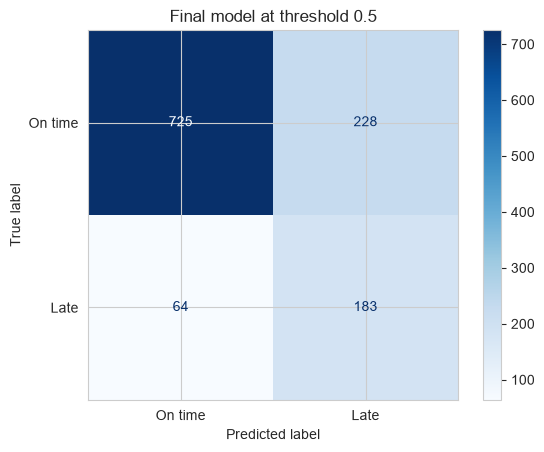

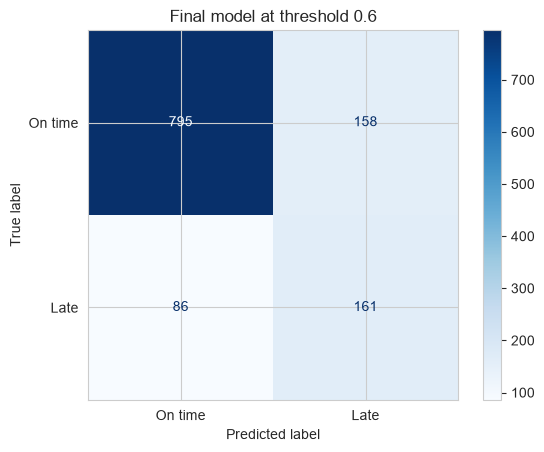

,Alerts sent,Late caught (TP),Late missed (FN),False alarms (FP),Precision,Recall,F1
Threshold,,,,,,,
0.5,411,183,64,228,0.445,0.741,0.556
0.6,319,161,86,158,0.505,0.652,0.569


In [26]:
# Compare two candidate thresholds on the test set
final_model.fit(X_train, y_train)
test_scores = final_model.predict_proba(X_test)[:, 1]

compare = []
for t in [0.50, 0.60]:
    pred = (test_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    compare.append({"Threshold": t,
                    "Alerts sent": pred.sum(),
                    "Late caught (TP)": tp,
                    "Late missed (FN)": fn,
                    "False alarms (FP)": fp,
                    "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred),
                    "F1": f1_score(y_test, pred)})
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["On time", "Late"]).plot(cmap="Blues")
    plt.title(f"Final model at threshold {t}")
    plt.show()

pd.DataFrame(compare).round(3).set_index("Threshold")

- Two thresholds were compared on the test set. At 0.50 the model catches 74% of late shipments but 228 alerts are false alarms. At 0.60 it catches 65% with 158 false alarms and the best F1 (0.569).
- Chosen: 0.60 for the Slack alerts (F1 was higher in cross-validation and dispatch gets fewer false alarms). 0.50 is kept as a "watch list" option if the business wants to catch more late shipments.

Why I picked 0.60

- F1 is at its peak. Training F1 is flat at 0.539 for both 0.55 and 0.60, so I took the higher one to cut false alarms.

- Alert fatigue is real. If dispatch gets too many false alarms, they stop trusting the messages.

- Still catches most of the risk. Recall stays above 60%.

## 10. Model Explainability
Which features drive the predictions, and in which direction?

Explainability answers one question: why does the model flag a shipment? Dispatch will only trust alerts they understand. I used two simple methods that suit logistic regression, and I ran both on your data.

- Permutation importance: shuffle one feature at a time and see how much the model gets worse. A big drop means the feature matters.

- Coefficients: show the direction. Positive pushes the risk up and negative pushes it down.

## permutation importance

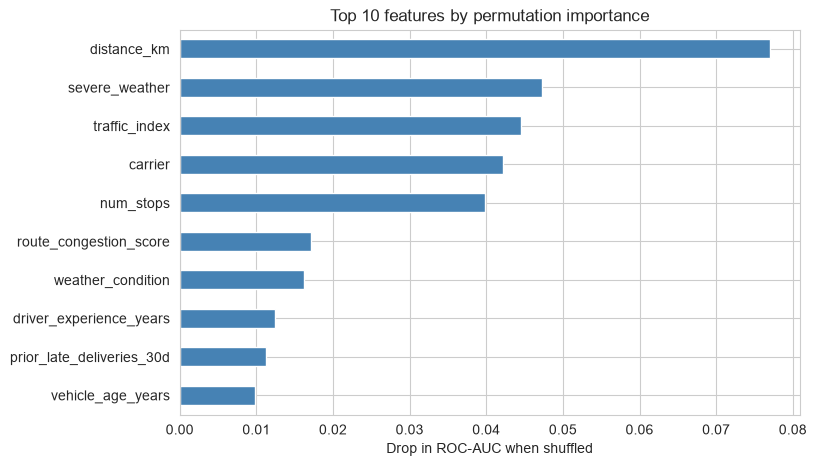

In [27]:
from sklearn.inspection import permutation_importance

# Drop in ROC-AUC when each original column is shuffled (test set)
pi = permutation_importance(final_model, X_test, y_test, scoring="roc_auc",
                            n_repeats=10, random_state=RANDOM_STATE)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(10)

imp.plot(kind="barh", color="steelblue", figsize=(8, 5),
         title="Top 10 features by permutation importance")
plt.xlabel("Drop in ROC-AUC when shuffled")
plt.show()

## coefficients

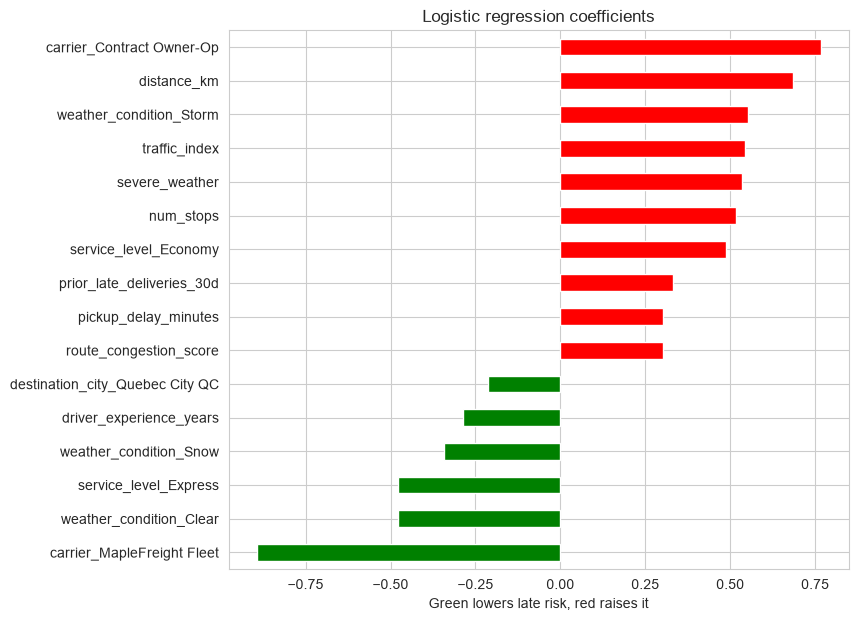

In [28]:
# Direction of each effect (numeric features are scaled, so sizes are comparable)
names = [n.split("__", 1)[1] for n in final_model.named_steps["pre"].get_feature_names_out()]
coef = pd.Series(final_model.named_steps["model"].coef_[0], index=names).sort_values()
top = pd.concat([coef.head(6), coef.tail(10)])

colors = ["green" if v < 0 else "red" for v in top]
top.plot(kind="barh", color=colors, figsize=(8, 7), title="Logistic regression coefficients")
plt.xlabel("Green lowers late risk, red raises it")
plt.show()

In [29]:
coef[coef.index.str.contains("weather")].round(2)

weather_condition_Clear     -0.48
weather_condition_Snow      -0.34
weather_condition_Fog        0.06
weather_condition_Rain       0.09
weather_condition_Unknown    0.11
severe_weather               0.54
weather_condition_Storm      0.55
dtype: float64

- Caveat: weather_condition_Snow has a negative coefficient because severe_weather already includes snow. The weather columns overlap, so they should be read together. Snow still raises late risk overall (34% late in the EDA).

**Findings**
- Top drivers by permutation importance: distance_km (0.077), severe_weather (0.047), traffic_index (0.045), carrier (0.042) and num_stops (0.040).
- Raising risk: contract owner-operators, long distance, storms, heavy traffic, more stops, Economy service, a high number of recent late deliveries by the carrier, and late pickups.
- Lowering risk: the MapleFreight Fleet, Express service, clear weather and experienced drivers.
- Customer tier and most city names have little effect, which matches the EDA.
- Dispatch can act on this: the strongest drivers (weather, traffic, carrier, stops) are known at dispatch time.

# **11. Slack Alert Integration**
Sending high-risk shipments to #dispatch-alerts through an incoming webhook. The webhook URL is loaded from .env and never printed.

In [30]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import os
import requests
from dotenv import load_dotenv

# Load the webhook from .env (never print it)
load_dotenv()
WEBHOOK_URL = os.getenv("SLACK_WEBHOOK_URL")
print("Webhook loaded:", WEBHOOK_URL is not None and WEBHOOK_URL.startswith("https://hooks.slack.com/"))

Webhook loaded: True


## finding high risk shipments

In [32]:
# Attach scores to the test shipments (X_test keeps the original row index)
alerts = df.loc[X_test.index, ["shipment_id", "origin_city", "destination_city", "carrier"]].copy()
alerts["risk_score"] = test_scores

high_risk = alerts[alerts["risk_score"] >= 0.60].sort_values("risk_score", ascending=False)
watch = alerts[(alerts["risk_score"] >= 0.50) & (alerts["risk_score"] < 0.60)]

print("High-risk shipments:", len(high_risk), "| Watch list:", len(watch))
high_risk.head(5)

High-risk shipments: 319 | Watch list: 92


,shipment_id,origin_city,destination_city,carrier,risk_score
5268,SHP-100936,Toronto ON,Calgary AB,PrairieLine,0.988166
1555,SHP-103230,Montreal QC,Regina SK,Contract Owner-Op,0.984296
2110,SHP-102910,Montreal QC,Edmonton AB,QuebecExpress,0.973695
3632,SHP-100273,Montreal QC,Hamilton ON,NorthStar Carriers,0.972804
955,SHP-101710,Montreal QC,Sudbury ON,MapleFreight Fleet,0.972615


## alert msg build

In [33]:
def build_message(high_risk, watch, top_n=5):
    lines = [f":rotating_light: *{len(high_risk)} shipments at risk of late delivery*",
             f"Watch list (risk 0.50-0.60): {len(watch)} more", "", "*Top risks:*"]
    for i, r in enumerate(high_risk.head(top_n).itertuples(), start=1):
        lines.append(f"{i}. `{r.shipment_id}` to {r.destination_city} | {r.carrier} | risk *{r.risk_score:.0%}*")
    lines += ["", "Action required: Re-route or warn the customer now."]
    return "\n".join(lines)

message = build_message(high_risk, watch)
print(message)

:rotating_light: *319 shipments at risk of late delivery*
Watch list (risk 0.50-0.60): 92 more

*Top risks:*
1. `SHP-100936` to Calgary AB | PrairieLine | risk *99%*
2. `SHP-103230` to Regina SK | Contract Owner-Op | risk *98%*
3. `SHP-102910` to Edmonton AB | QuebecExpress | risk *97%*
4. `SHP-100273` to Hamilton ON | NorthStar Carriers | risk *97%*
5. `SHP-101710` to Sudbury ON | MapleFreight Fleet | risk *97%*

Action required: Re-route or warn the customer now.


## send message

In [34]:
# Post to #dispatch-alerts (the URL is never printed)
response = requests.post(WEBHOOK_URL, json={"text": message}, timeout=10)
print("Slack status:", response.status_code)
response.raise_for_status()

Slack status: 200


**Findings**
- At threshold 0.60, 319 test shipments are flagged high-risk and 92 more are on the 0.50-0.60 watch list.
- The alert shows the count and the top 5 shipments with ID, destination, carrier and risk score.
- The webhook URL is loaded from .env and never printed. A screenshot of the message is saved in screenshots/slack_alert.png.

# **12. Recommendations**
Actions MapleFreight can take to improve on-time performance, based on the drivers found in the EDA and the model.

In [35]:
# Late rate for the key risk groups vs the overall rate
overall = df["delivered_late"].mean()
groups = {
    "Contract Owner-Op carrier": df["carrier"] == "Contract Owner-Op",
    "MapleFreight Fleet carrier": df["carrier"] == "MapleFreight Fleet",
    "Storm or snow forecast": df["weather_condition"].isin(["Storm", "Snow"]),
    "4-5 stops": df["num_stops"] >= 4,
    "Economy service": df["service_level"] == "Economy",
    "Pickup 40+ min late": df["pickup_delay_minutes"] > 40,
}
evidence = pd.DataFrame({
    "Shipments": {k: m.sum() for k, m in groups.items()},
    "Late rate": {k: df.loc[m, "delivered_late"].mean() for k, m in groups.items()},
})
evidence["Vs overall"] = evidence["Late rate"] / overall
print(f"Overall late rate: {overall:.1%}")
evidence.round(3)

Overall late rate: 20.6%


,Shipments,Late rate,Vs overall
Contract Owner-Op carrier,622,0.360,1.751
MapleFreight Fleet carrier,2378,0.128,0.624
Storm or snow forecast,1147,0.368,1.789
4-5 stops,1960,0.286,1.392
Economy service,1265,0.266,1.291
Pickup 40+ min late,1544,0.276,1.342


**Findings and recommendations**

1. **Use the Slack alerts every shift.** At threshold 0.60 the model catches about 65% of late shipments, and about half of the alerts are real. Dispatch should review the top alerts at pickup and again mid-route, then re-route or warn the customer before the window closes.
2. **Review contract owner-operators.** They are late about 36% of the time vs 13% for the MapleFreight Fleet. Set performance targets, add penalties or incentives in contracts, and give them the best-reliability routes.
3. **Add a weather check before dispatch.** Storm shipments are late 47% of the time and snow 34%, vs 14% in clear weather. Before each departure, dispatch should check the forecast along the route. For snow or storm, they can:
   - delay departure or pick a safer route,
   - add buffer hours to the promised window,
   - warn the customer in advance,
   - assign an experienced driver and a newer vehicle (driver experience lowers late risk in the model).
4. **Limit stops on time-critical routes.** Late rate climbs from 12% with no stops to 29% with five. Consolidate stops or use direct routes for Express and high-value accounts.
5. **Act on late pickups immediately.** A pickup more than 40 minutes late has a late-delivery rate near 28%. Dispatch should trigger a check as soon as pickup slips.
6. **Set realistic Economy promises.** Economy is late 27% of the time vs 15% for Express. Quote longer windows or add buffer to Economy.
7. **Use the model as a tool, not a verdict.** It is mostly right about risk, but half of the flagged shipments arrive on time. Track the model monthly and retrain as new data comes in.
8. **Enforce a full pre-trip inspection before dispatch.** Check the truck top to bottom, including engine, brakes, tires, lights and body, using the daily inspection that Ontario already requires for commercial vehicles. Dispatch should not release a truck until the inspection report is complete. Fixing a defect before departure is cheaper than a breakdown mid-route that makes the delivery late. Newer fleets benefit too, since vehicle age has a small positive link to lateness in this data (correlation 0.06).

**Limitations:** the data comes from one export with no cost figures, so the threshold is balanced rather than cost-optimised. Customer tier and city had little effect.